# Nacimientos diarios: LSTM vs modelos tradicionales

Comparamos un LSTM contra Naive, ARIMA y SARIMA para predecir nacimientos diarios (1959).

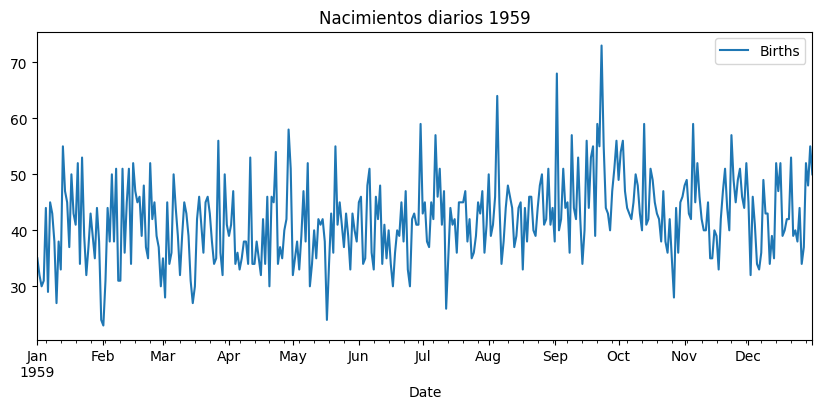

,Births
count,365.000000
mean,41.980822
std,7.348257
min,23.000000
25%,37.000000
50%,42.000000
75%,46.000000
max,73.000000


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv('daily-total-female-births.csv', parse_dates=['Date'], index_col='Date')
df.index.freq = 'D'
df.plot(figsize=(10, 4), title='Nacimientos diarios 1959')
plt.show()
df.describe()

## Estacionalidad

Vemos ACF/PACF y descomponemos la serie (periodo 7, semanal).

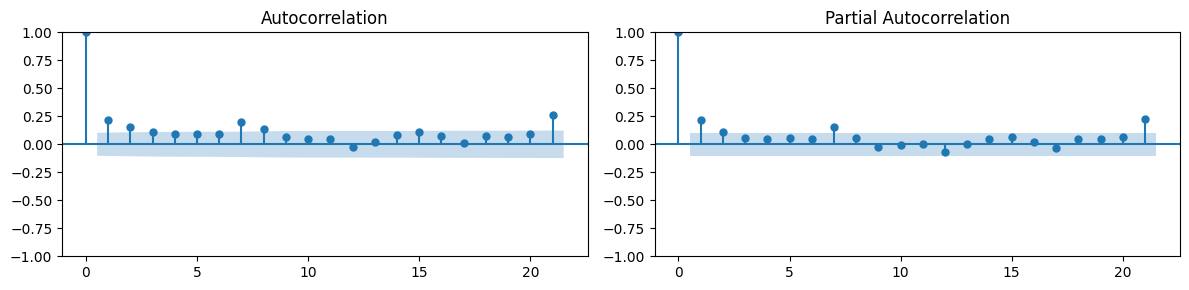

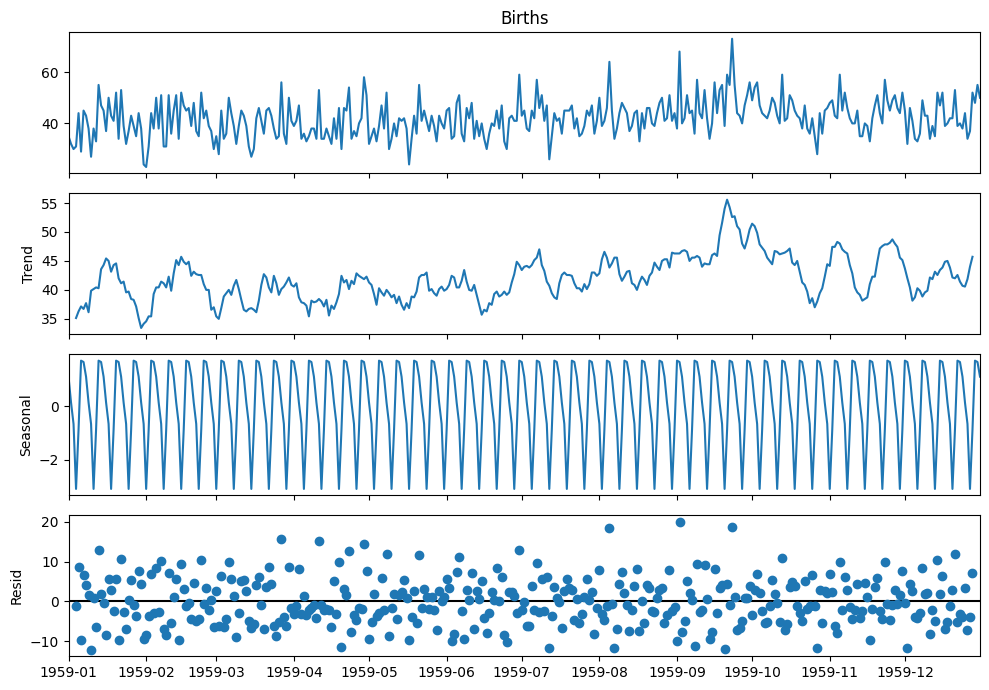

In [2]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_acf(df['Births'], lags=21, ax=axes[0])
plot_pacf(df['Births'], lags=21, ax=axes[1])
plt.tight_layout()
plt.show()

decomposition = seasonal_decompose(df['Births'], model='additive', period=7)
decomposition.plot()
plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.show()

Hay un pico chico en lag-1 y otro en lag-7. Por eso usamos `s=7` en el SARIMA.

## Train/test
Últimos 30 días como test.

In [3]:
series = df['Births'].values.astype('float32')
n_test = 30
train, test = series[:-n_test], series[-n_test:]
print(f'train={len(train)}  test={len(test)}')

train=335  test=30


## Modelos tradicionales

- **Naive**: repite el último valor.
- **ARIMA**: modelo clásico de series de tiempo.
- **SARIMA**: ARIMA + estacionalidad semanal (s=7).

Comparamos modelos estadísticos (ARIMA/SARIMA) contra una red neuronal (LSTM).

In [4]:
# Naive: cada predicción = último valor conocido en ese punto (rolling)
history = list(train)
naive_preds = []
for obs in test:
    naive_preds.append(history[-1])
    history.append(obs)
naive_preds = np.array(naive_preds)

In [5]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train)
arima_preds = []
for obs in test:
    model = ARIMA(history, order=(5, 1, 0))
    fit = model.fit()
    yhat = fit.forecast()[0]
    arima_preds.append(yhat)
    history.append(obs)
arima_preds = np.array(arima_preds)

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

history = list(train)
sarima_preds = []
for obs in test:
    model = SARIMAX(history, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    yhat = fit.forecast()[0]
    sarima_preds.append(yhat)
    history.append(obs)
sarima_preds = np.array(sarima_preds)

## Modelo LSTM

Dividimos en entrenamiento (305 días), validación (30 días, para early stopping) y test (30 días, igual que los otros modelos). Escalamos con `MinMaxScaler` ajustado solo con entrenamiento y armamos ventanas de 7 días.

In [7]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

look_back = 7
n_val = 30

# División: entrenamiento / validación (el "train" original ya excluye el test de 30 días)
train_lstm, val_lstm = train[:-n_val], train[-n_val:]
print(f'entrenamiento={len(train_lstm)}  validacion={len(val_lstm)}  test={len(test)}')

# Preparación: escalado ajustado SOLO con entrenamiento (sin fuga de datos)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_lstm.reshape(-1, 1)).flatten()
# la validación se transforma con el mismo scaler, incluyendo look_back días previos de
# entrenamiento para poder construir sus primeras ventanas
val_scaled = scaler.transform(np.concatenate([train_lstm[-look_back:], val_lstm]).reshape(-1, 1)).flatten()

def make_supervised(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

X_train, y_train = make_supervised(train_scaled, look_back)
X_train = X_train.reshape((X_train.shape[0], look_back, 1))

X_val, y_val = make_supervised(val_scaled, look_back)
X_val = X_val.reshape((X_val.shape[0], look_back, 1))

keras.utils.set_random_seed(42)

lstm_model = keras.Sequential([
    layers.Input(shape=(look_back, 1)),
    layers.LSTM(32),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_fit = lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                              epochs=200, batch_size=8, callbacks=[early_stop], verbose=0)
print(f"epochs entrenadas: {len(history_fit.history['loss'])}")
print('loss entrenamiento final:', history_fit.history['loss'][-1])
print('loss validación final:', history_fit.history['val_loss'][-1])

entrenamiento=305  validacion=30  test=30


epochs entrenadas: 11
loss entrenamiento final: 0.020867658779025078
loss validación final: 0.015407679602503777


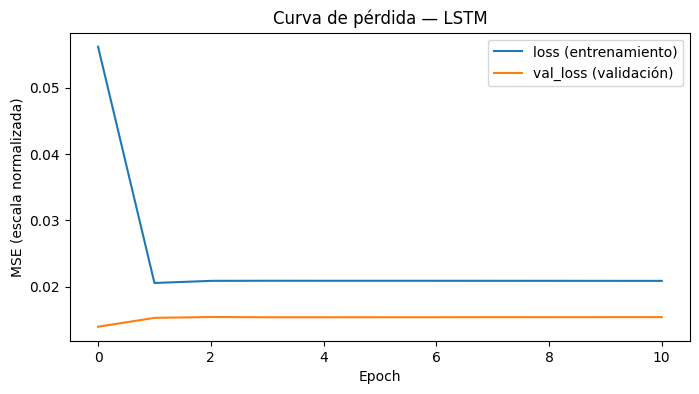

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history_fit.history['loss'], label='loss (entrenamiento)')
plt.plot(history_fit.history['val_loss'], label='val_loss (validación)')
plt.title('Curva de pérdida — LSTM')
plt.xlabel('Epoch')
plt.ylabel('MSE (escala normalizada)')
plt.legend()
plt.show()

In [9]:
# Predicción walk-forward: la ventana se desliza incorporando el valor real observado
full_scaled = scaler.transform(series.reshape(-1, 1)).flatten()
start = len(train) - look_back

lstm_preds_scaled = []
for i in range(len(test)):
    window = full_scaled[start + i: start + i + look_back].reshape(1, look_back, 1)
    pred = lstm_model.predict(window, verbose=0)[0, 0]
    lstm_preds_scaled.append(pred)

lstm_preds = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1, 1)).flatten()

## Comparación de resultados

In [10]:
def report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'modelo': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}

results = pd.DataFrame([
    report('Naive', test, naive_preds),
    report('ARIMA(5,1,0)', test, arima_preds),
    report('SARIMA(1,1,1)(1,0,1)7', test, sarima_preds),
    report('LSTM', test, lstm_preds),
]).set_index('modelo')
results

,RMSE,MAE,MAPE (%)
modelo,,,
Naive,8.308630,6.700000,15.847668
"ARIMA(5,1,0)",7.267023,6.022331,14.398844
"SARIMA(1,1,1)(1,0,1)7",6.705052,5.650650,13.866408
LSTM,7.215102,6.260027,15.604721


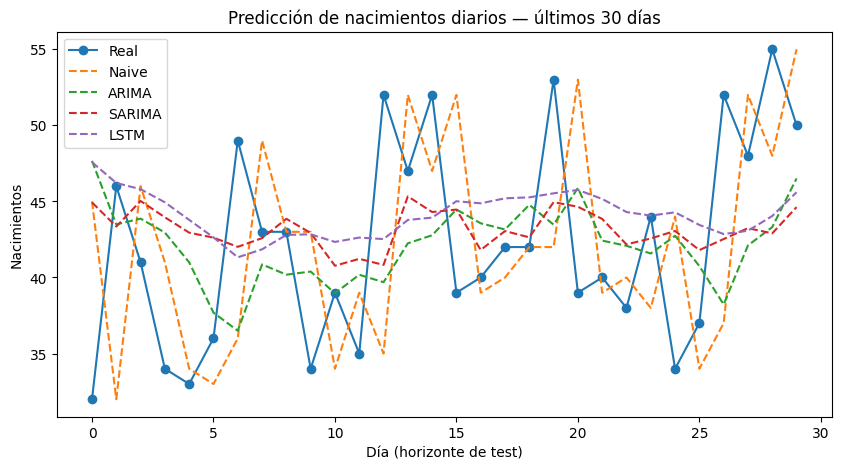

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(test, label='Real', marker='o')
plt.plot(naive_preds, label='Naive', linestyle='--')
plt.plot(arima_preds, label='ARIMA', linestyle='--')
plt.plot(sarima_preds, label='SARIMA', linestyle='--')
plt.plot(lstm_preds, label='LSTM', linestyle='--')
plt.title('Predicción de nacimientos diarios — últimos 30 días')
plt.xlabel('Día (horizonte de test)')
plt.ylabel('Nacimientos')
plt.legend()
plt.show()

## Pronóstico a futuro

Reentrenamos SARIMA con toda la serie y proyectamos 30 días hacia adelante, con intervalo de confianza del 95%.

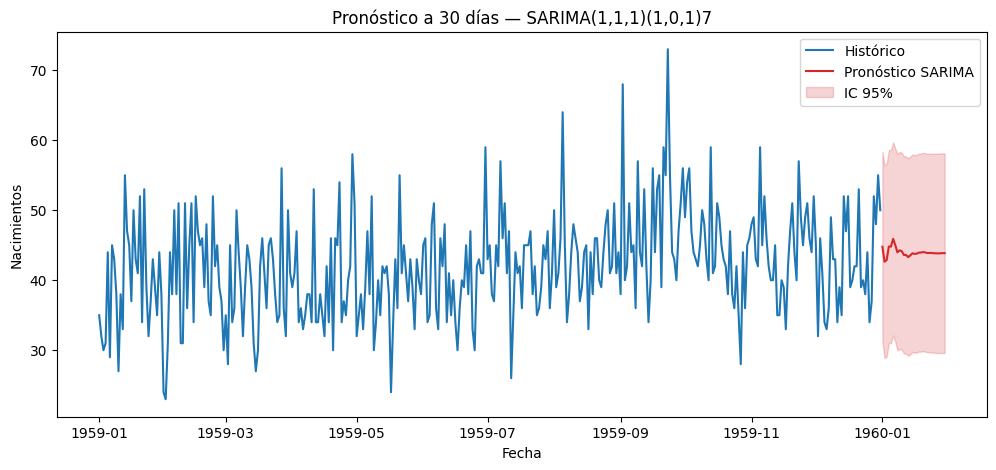

1960-01-01    44.787805
1960-01-02    42.637448
1960-01-03    42.888421
1960-01-04    44.813043
1960-01-05    44.796561
Freq: D, dtype: float64

In [12]:
final_model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
                       enforce_stationarity=False, enforce_invertibility=False)
final_fit = final_model.fit(disp=False)

horizon = 30
forecast = final_fit.get_forecast(steps=horizon)
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=horizon, freq='D')
future_mean = pd.Series(forecast.predicted_mean, index=future_dates)
conf_int = pd.DataFrame(forecast.conf_int(alpha=0.05), index=future_dates, columns=['lower', 'upper'])

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Births'], label='Histórico')
plt.plot(future_mean.index, future_mean, label='Pronóstico SARIMA', color='tab:red')
plt.fill_between(conf_int.index, conf_int['lower'], conf_int['upper'],
                  color='tab:red', alpha=0.2, label='IC 95%')
plt.title(f'Pronóstico a {horizon} días — SARIMA(1,1,1)(1,0,1)7')
plt.xlabel('Fecha')
plt.ylabel('Nacimientos')
plt.legend()
plt.show()

future_mean.head()

## Conclusión

| modelo | RMSE | MAE | MAPE |
|---|---|---|---|
| Naive | 8.31 | 6.70 | 15.85% |
| ARIMA(5,1,0) | 7.27 | 6.02 | 14.40% |
| **SARIMA(1,1,1)(1,0,1)7** | **6.71** | **5.65** | **13.87%** |
| LSTM | 7.22 | 6.26 | 15.60% |

SARIMA gana en las tres métricas. Con pocos datos (~300 días) y una serie casi ruido blanco, el LSTM no logra superar a un modelo estadístico simple. Para esta serie, SARIMA(s=7) es la mejor opción.